In [312]:
import numpy as np
import pandas as pd
import time
from datetime import datetime
from IPython.display import display

# matplotlib for visualization
import matplotlib.pyplot as plt
%matplotlib inline

# seaborn for statistical data visualization
import seaborn as sns

# import module for splitting and cross-validation using gridsearch
from sklearn.model_selection import train_test_split, GridSearchCV

# import modules for preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
pd.options.mode.chained_assignment = None # to avoid SettingWithCopyWarning after scaling

# import machine learning module from the sklearn library
from sklearn.dummy import DummyClassifier # import dummy classifier
from sklearn.tree import DecisionTreeClassifier # import decision tree classifier
from sklearn.linear_model import LogisticRegression # import logistic regression 
from sklearn.ensemble import RandomForestClassifier # import random forest algorith
#from catboost import CatBoostClassifier # import catboost classifier
#from lightgbm import LGBMClassifier # import lightgbm classifier
#from xgboost import XGBClassifier # import xgboost classifier

# import metrics for sanity check on model
from sklearn import metrics
from sklearn.metrics import *
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, balanced_accuracy_score, roc_auc_score

# import warnings
import warnings
warnings.filterwarnings('ignore')

# import sklearn utilities
from sklearn.utils import shuffle

import pickle as pk
import joblib
import streamlit as st

print('Project libraries has been successfully been imported!')

Project libraries has been successfully been imported!


In [313]:
try:
    status_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_status.xlsx")
    services_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_services.xlsx")
    population_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_population.xlsx")
    location_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_location.xlsx")
    demo_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_demographics.xlsx")
except:
    status_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_status.xlsx")
    services_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_services.xlsx")
    population_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_population.xlsx")
    location_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_location.xlsx")
    demo_df=pd.read_excel("C:/Users/obado/Desktop/ipynb/ML/telco_customer_churn_demographics.xlsx")

In [314]:
# --- Example Data ---
data = pd.DataFrame({
    'Education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor'],
    'Color': ['Red', 'Blue', 'Green', 'Blue', 'Red'],
    'Age': [25, 32, 45, 28, 40],
    'Income': [40000, 55000, 70000, 48000, 60000],
    'Target': [0, 1, 0, 1, 0]
})

# --- Detect column types ---
numeric_features = data.select_dtypes(include=['int64', 'float64']).columns.drop('Target').tolist()
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()

# Specify which categorical columns are ordinal (if known)
ordinal_features = ['Education']
# Remaining categorical columns are nominal
nominal_features = [col for col in categorical_features if col not in ordinal_features]

# --- Define ordinal mapping ---
education_categories = ['High School', 'Bachelor', 'Master', 'PhD']

# --- Column Transformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[education_categories]), ordinal_features),
        ('nom', OneHotEncoder(drop='first'), nominal_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# --- Train-test split ---
X = data.drop('Target', axis=1)
y = data['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Pipeline for Linear Model ---
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
linear_pipeline.fit(X_train, y_train)
print("Linear model score:", linear_pipeline.score(X_test, y_test))

# --- Pipeline for Tree-Based Model ---
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
tree_pipeline.fit(X_train, y_train)
print("Tree model score:", tree_pipeline.score(X_test, y_test))

Linear model score: 0.5
Tree model score: 0.5


In [315]:
def get_info(df, name):
    print(f"General information about the {name} dataset")
    print("-"*120)
    print("Head: ")
    print()
    display(df.head())
    print("-"*120)
    print(f"Description of {name} dataset")
    display(df.describe())
    print("-"*120)
    display(df.describe(include="object"))
    print("-"*120)
    print(f"Information on {name} dataset")
    display(df.info())
    print("-"*120)
    print(f"Shape of {name} dataset")
    display(df.shape)
    print("-"*120)
    print(f"Check to see if there is any duplicate in {name} dataset")
    display(df.duplicated().sum())
    print("-"*120)
    print(f"Percentage of NaN value in {name} dataset")
    display(df.isnull().sum()/len(df))
get_info(status_df, "STATUS")

General information about the STATUS dataset
------------------------------------------------------------------------------------------------------------------------
Head: 



,Customer ID,Count,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,1,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,1,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,1,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,1,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,1,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


------------------------------------------------------------------------------------------------------------------------
Description of STATUS dataset


,Count,Satisfaction Score,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,3.244924,0.265370,58.505040,4400.295755
std,0.0,1.201657,0.441561,21.170031,1183.057152
min,1.0,1.000000,0.000000,5.000000,2003.000000
25%,1.0,3.000000,0.000000,40.000000,3469.000000
50%,1.0,3.000000,0.000000,61.000000,4527.000000
75%,1.0,4.000000,1.000000,75.500000,5380.500000
max,1.0,5.000000,1.000000,96.000000,6500.000000


------------------------------------------------------------------------------------------------------------------------


...

(7043, 11)

------------------------------------------------------------------------------------------------------------------------
Check to see if there is any duplicate in STATUS dataset


0

------------------------------------------------------------------------------------------------------------------------
Percentage of NaN value in STATUS dataset


Customer ID           0.00000
Count                 0.00000
Quarter               0.00000
Satisfaction Score    0.00000
Customer Status       0.00000
Churn Label           0.00000
Churn Value           0.00000
Churn Score           0.00000
CLTV                  0.00000
Churn Category        0.73463
Churn Reason          0.73463
dtype: float64

In [316]:
get_info(location_df, "LOCATION")

General information about the LOCATION dataset
------------------------------------------------------------------------------------------------------------------------
Head: 



,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
0,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582
1,7495-OOKFY,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
2,1658-BYGOY,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
3,4598-XLKNJ,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4,4846-WHAFZ,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


------------------------------------------------------------------------------------------------------------------------
Description of LOCATION dataset


,Count,Zip Code,Latitude,Longitude
count,7043.0,7043.000000,7043.000000,7043.000000
mean,1.0,93486.070567,36.197455,-119.756684
std,0.0,1856.767505,2.468929,2.154425
min,1.0,90001.000000,32.555828,-124.301372
25%,1.0,92101.000000,33.990646,-121.788090
50%,1.0,93518.000000,36.205465,-119.595293
75%,1.0,95329.000000,38.161321,-117.969795
max,1.0,96150.000000,41.962127,-114.192901


------------------------------------------------------------------------------------------------------------------------


...

(7043, 9)

------------------------------------------------------------------------------------------------------------------------
Check to see if there is any duplicate in LOCATION dataset


0

------------------------------------------------------------------------------------------------------------------------
Percentage of NaN value in LOCATION dataset


Customer ID    0.0
Count          0.0
Country        0.0
State          0.0
City           0.0
Zip Code       0.0
Lat Long       0.0
Latitude       0.0
Longitude      0.0
dtype: float64

In [317]:
location_df.columns

Index(['Customer ID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude'],
      dtype='object')

In [318]:

get_info(demo_df, "DEMOGRAPHICS")
#head,describe,info,shape,duplicate

General information about the DEMOGRAPHICS dataset
------------------------------------------------------------------------------------------------------------------------
Head: 



,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,1,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,1,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,1,Female,80,No,Yes,Yes,Yes,1


------------------------------------------------------------------------------------------------------------------------
Description of DEMOGRAPHICS dataset


,Count,Age,Number of Dependents
count,7043.0,7043.000000,7043.000000
mean,1.0,46.509726,0.468692
std,0.0,16.750352,0.962802
min,1.0,19.000000,0.000000
25%,1.0,32.000000,0.000000
50%,1.0,46.000000,0.000000
75%,1.0,60.000000,0.000000
max,1.0,80.000000,9.000000


------------------------------------------------------------------------------------------------------------------------


...

(7043, 9)

------------------------------------------------------------------------------------------------------------------------
Check to see if there is any duplicate in DEMOGRAPHICS dataset


0

------------------------------------------------------------------------------------------------------------------------
Percentage of NaN value in DEMOGRAPHICS dataset


Customer ID             0.0
Count                   0.0
Gender                  0.0
Age                     0.0
Under 30                0.0
Senior Citizen          0.0
Married                 0.0
Dependents              0.0
Number of Dependents    0.0
dtype: float64

In [319]:
get_info(services_df, "SERVICES")

General information about the SERVICES dataset
------------------------------------------------------------------------------------------------------------------------
Head: 



,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,8779-QRDMV,1,Q3,No,0,1,None,No,0.00,No,...,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65
1,7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,...,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10
2,1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88
3,4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07
4,4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36


------------------------------------------------------------------------------------------------------------------------
Description of SERVICES dataset


,Count,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,0.0,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,1.0,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,1.0,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,1.0,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,1.0,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,1.0,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


------------------------------------------------------------------------------------------------------------------------


...

(7043, 30)

------------------------------------------------------------------------------------------------------------------------
Check to see if there is any duplicate in SERVICES dataset


0

------------------------------------------------------------------------------------------------------------------------
Percentage of NaN value in SERVICES dataset


Customer ID                          0.0
Count                                0.0
Quarter                              0.0
Referred a Friend                    0.0
Number of Referrals                  0.0
Tenure in Months                     0.0
Offer                                0.0
Phone Service                        0.0
Avg Monthly Long Distance Charges    0.0
Multiple Lines                       0.0
Internet Service                     0.0
Internet Type                        0.0
Avg Monthly GB Download              0.0
Online Security                      0.0
Online Backup                        0.0
Device Protection Plan               0.0
Premium Tech Support                 0.0
Streaming TV                         0.0
Streaming Movies                     0.0
Streaming Music                      0.0
Unlimited Data                       0.0
Contract                             0.0
Paperless Billing                    0.0
Payment Method                       0.0
Monthly Charge  

In [320]:
# joining datasets 
merged_df = pd.merge(services_df, location_df, on=["Customer ID", 'Count'], how='left')
merged_df1 = pd.merge(merged_df, demo_df, on=["Customer ID", 'Count'], how='left')
telecom_churn_df = pd.merge(merged_df1, status_df, on=["Customer ID", 'Count', 'Quarter'], how='left')
telecom_churn_df.columns
#merged_df2 = merged_df2.fillna('No')
#merged_df2.sample(5)

Index(['Customer ID', 'Count', 'Quarter', 'Referred a Friend',
       'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Country', 'State', 'City', 'Zip Code', 'Lat Long',
       'Latitude', 'Longitude', 'Gender', 'Age', 'Under 30', 'Senior Citizen',
       'Married', 'Dependents', 'Number of Dependents', 'Satisfaction Score',
       'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV',
       'Churn Category', 'Churn Reason'],
      dtype='objec

In [321]:
telecom_churn_df.sample(3)

,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Dependents,Number of Dependents,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
6795,0048-PIHNL,1,Q3,Yes,5,49,Offer B,Yes,49.58,No,...,No,0,3,Stayed,No,0,20,6061,NaN,NaN
1484,4116-TZAQJ,1,Q3,No,0,9,None,Yes,13.86,No,...,No,0,1,Churned,Yes,1,76,5393,Attitude,Attitude of support person
5574,7544-ZVIKX,1,Q3,Yes,2,58,None,Yes,33.82,Yes,...,Yes,2,5,Stayed,No,0,75,5870,NaN,NaN


In [322]:
telecom_churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Count                              7043 non-null   int64  
 2   Quarter                            7043 non-null   object 
 3   Referred a Friend                  7043 non-null   object 
 4   Number of Referrals                7043 non-null   int64  
 5   Tenure in Months                   7043 non-null   int64  
 6   Offer                              7043 non-null   object 
 7   Phone Service                      7043 non-null   object 
 8   Avg Monthly Long Distance Charges  7043 non-null   float64
 9   Multiple Lines                     7043 non-null   object 
 10  Internet Service                   7043 non-null   object 
 11  Internet Type                      7043 non-null   objec

In [323]:
telecom_churn_df=telecom_churn_df.drop(labels=['Customer ID', 'Count', 'Quarter','Churn Label', 'Lat Long', 'Churn Category', 'Churn Reason', 'Country', 'State', 'City', 'Zip Code'],axis=1)

<AxesSubplot:>

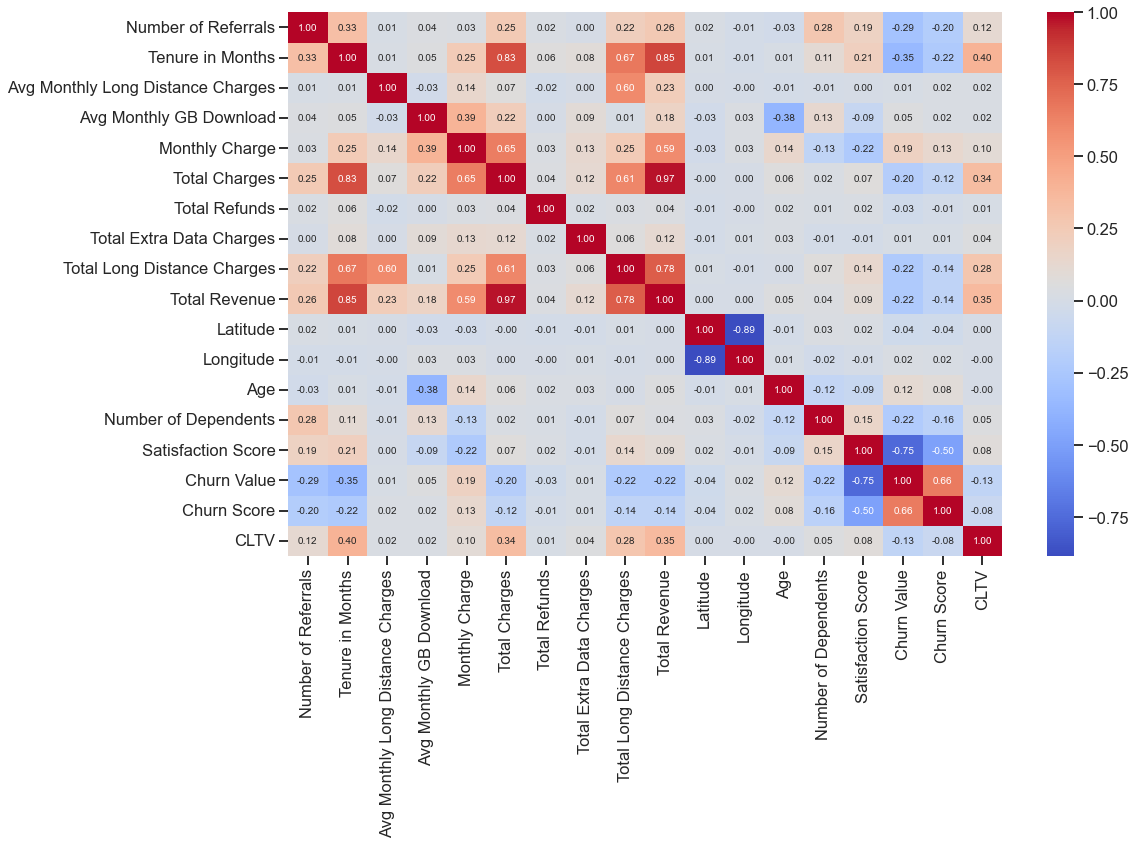

In [324]:
corr_df=telecom_churn_df.corr()
plt.figure(figsize=(16,10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm',fmt='.2f')

0    0.73463
1    0.26537
Name: Churn Value, dtype: float64


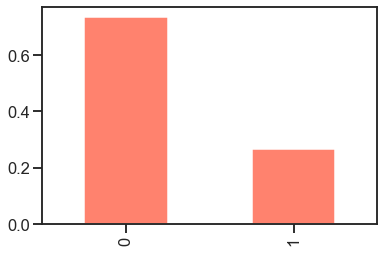

In [325]:
churn_percentage=telecom_churn_df["Churn Value"].value_counts(normalize=True)
churn_percentage.plot(kind="bar")

print(churn_percentage)

In [326]:
telecom_churn_df.groupby('Gender').sum()

,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Latitude,Longitude,Age,Number of Dependents,Satisfaction Score,Churn Value,Churn Score,CLTV
Gender,,,,,,,,,,,,,,,,,,
Female,6904,112519,79529.82,72569,227432.4,7955182.20,6712.62,24100,2579792.41,10552361.99,126143.100918,-417611.051074,162097,1615,11335,939,204018,15376770
Male,6843,115581,82170.09,71921,228684.2,8105543.04,7107.03,24220,2696113.69,10818769.70,128795.573392,-425835.272043,165471,1686,11519,930,208033,15614513


In [327]:
telecom_churn_df.groupby('Gender')["Churn Value"].value_counts(normalize=True)

Gender  Churn Value
Female  0              0.730791
        1              0.269209
Male    0              0.738397
        1              0.261603
Name: Churn Value, dtype: float64

In [328]:
telecom_churn_df.groupby('Senior Citizen')["Churn Value"].value_counts(normalize=True)

Senior Citizen  Churn Value
No              0              0.763938
                1              0.236062
Yes             0              0.583187
                1              0.416813
Name: Churn Value, dtype: float64

In [329]:
telecom_churn_df["Senior Citizen"].value_counts(normalize=True)

No     0.837853
Yes    0.162147
Name: Senior Citizen, dtype: float64

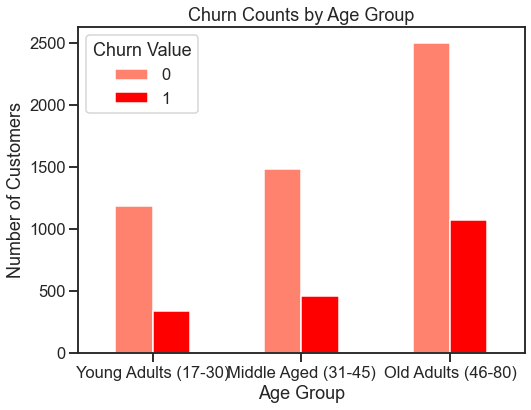

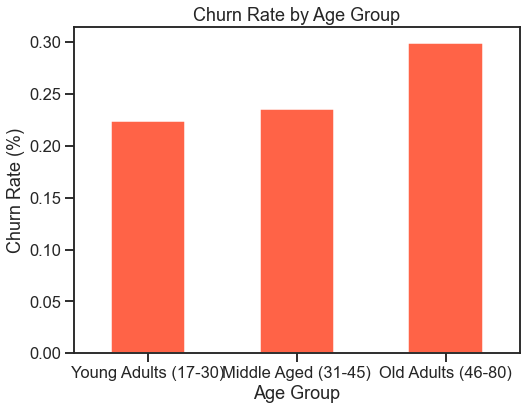

Churn Rate by Age Group:
AgeGroup
Young Adults (17-30)    0.223676
Middle Aged (31-45)     0.235203
Old Adults (46-80)      0.299636
Name: 1, dtype: float64


In [330]:
import matplotlib.pyplot as plt
# Define bins and labels
bins = [17, 30, 45, 80]
labels = ["Young Adults (17-30)", "Middle Aged (31-45)", "Old Adults (46-80)"]

# Cut ages into groups
telecom_churn_df["AgeGroup"] = pd.cut(telecom_churn_df["Age"], bins=bins, labels=labels, include_lowest=True)

# Group by AgeGroup and Churn
churn_by_age = telecom_churn_df.groupby(["AgeGroup", "Churn Value"]).size().unstack(fill_value=0)

# Normalize to get churn rate per group
churn_rate = churn_by_age.div(churn_by_age.sum(axis=1), axis=0)

# Plot churn counts
churn_by_age.plot(kind="bar", figsize=(8,6))
plt.title("Churn Counts by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()
# Plot churn rates
churn_rate[1].plot(kind="bar", figsize=(8,6), color="tomato")
plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

# Print churn rates
print("Churn Rate by Age Group:")
print(churn_rate[1])


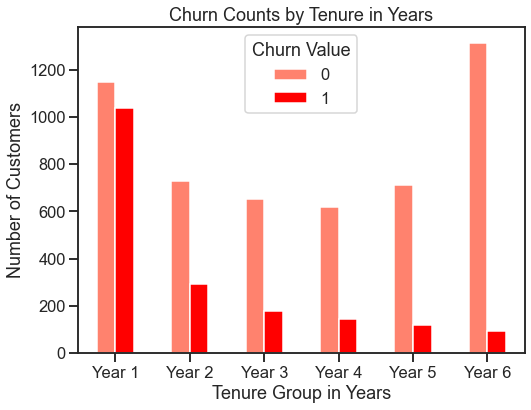

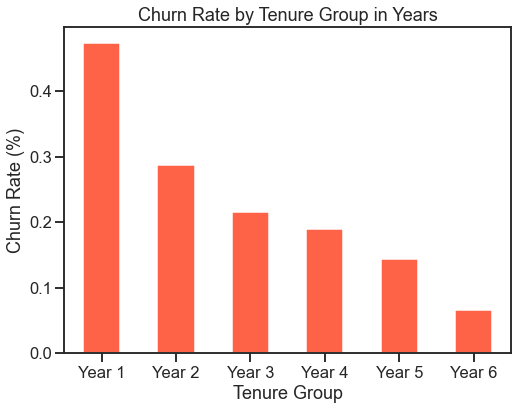

Churn Rate by Tenure Group in Years:
Tenure_Group
Year 1    0.474382
Year 2    0.287109
Year 3    0.216346
Year 4    0.190289
Year 5    0.144231
Year 6    0.066098
Name: 1, dtype: float64


In [331]:
import matplotlib.pyplot as plt
# Define bins and labels
bins = [1, 12, 24, 36, 48, 60, 72]
labels = ["Year 1", "Year 2", "Year 3", "Year 4", "Year 5", "Year 6"]

# Cut ages into groups
telecom_churn_df["Tenure_Group"] = pd.cut(telecom_churn_df["Tenure in Months"], bins=bins, labels=labels, include_lowest=True)

# Group by AgeGroup and Churn
churn_by_tenure = telecom_churn_df.groupby(["Tenure_Group", "Churn Value"]).size().unstack(fill_value=0)

# Normalize to get churn rate per group
churn_rate = churn_by_tenure.div(churn_by_tenure.sum(axis=1), axis=0)

# Plot churn counts
churn_by_tenure.plot(kind="bar", figsize=(8,6))
plt.title("Churn Counts by Tenure in Years")
plt.xlabel("Tenure Group in Years")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()
# Plot churn rates
churn_rate[1].plot(kind="bar", figsize=(8,6), color="tomato")
plt.title("Churn Rate by Tenure Group in Years")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

# Print churn rates
print("Churn Rate by Tenure Group in Years:")
print(churn_rate[1])


In [332]:
telecom_churn_df=telecom_churn_df.drop(columns=["AgeGroup", "Tenure_Group"], axis=1)

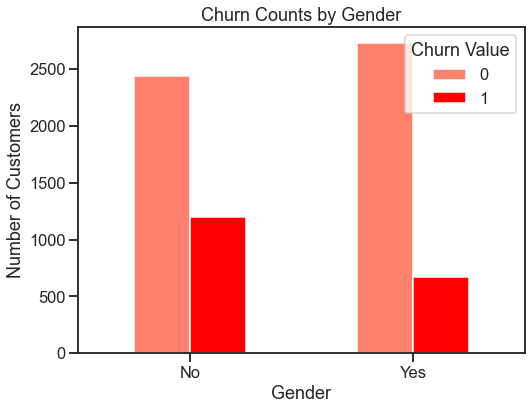

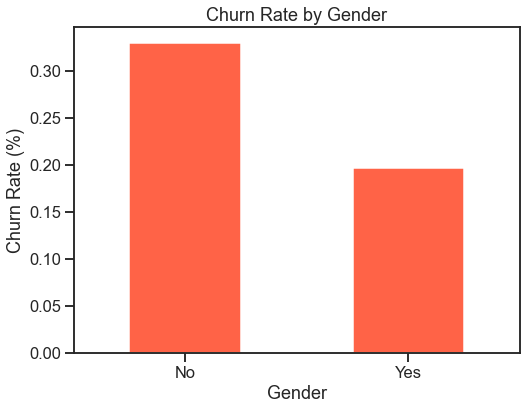

Churn Rate by Gender:
Married
No     0.329580
Yes    0.196649
Name: 1, dtype: float64


In [333]:
# Group by AgeGroup and Churn
churn_by_marr = telecom_churn_df.groupby(["Married", "Churn Value"]).size().unstack(fill_value=0)

# Normalize to get churn rate per group
churn_rates = churn_by_marr.div(churn_by_marr.sum(axis=1), axis=0)

# Plot churn counts
churn_by_marr.plot(kind="bar", figsize=(8,6))
plt.title("Churn Counts by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()
# Plot churn rates
churn_rates[1].plot(kind="bar", figsize=(8,6), color="tomato")
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

# Print churn rates
print("Churn Rate by Gender:")
print(churn_rates[1])

<AxesSubplot:xlabel='Churn Value', ylabel='Tenure in Months'>

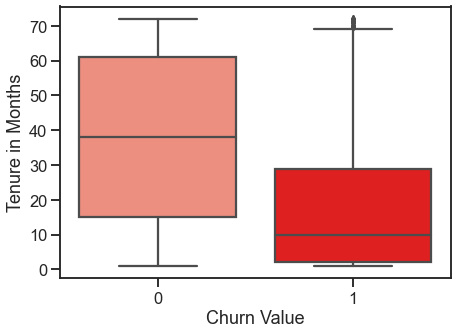

In [334]:
import seaborn as sns
plt.figure(figsize=(7,5))
sns.boxplot(x="Churn Value", y='Tenure in Months', data=telecom_churn_df)

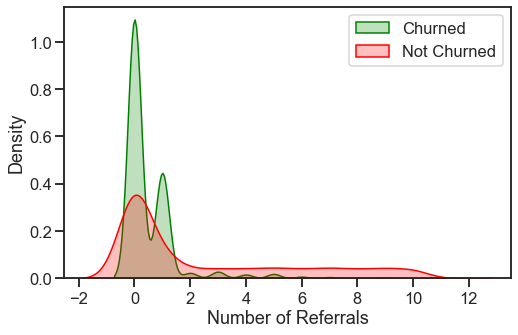

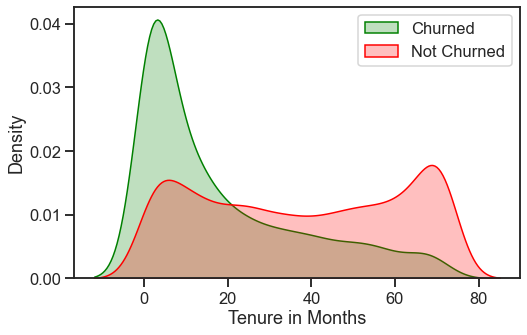

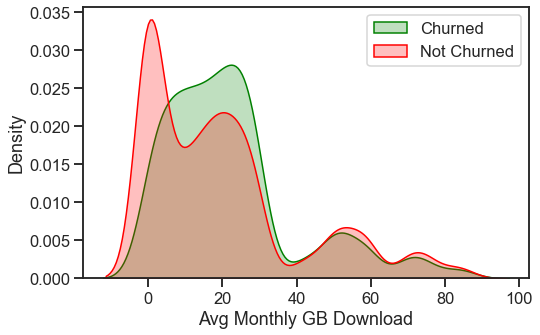

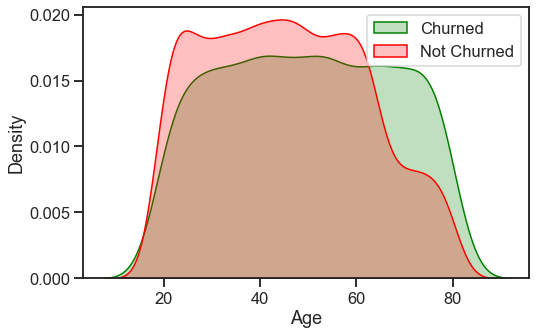

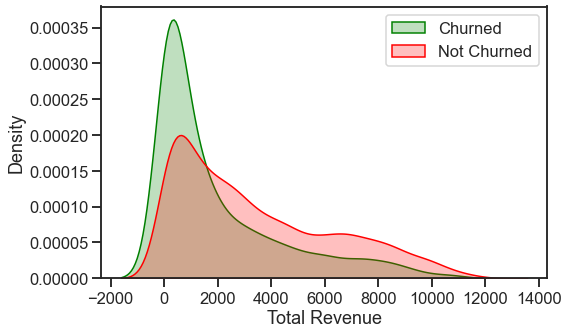

In [335]:
def plot_kde_by_churn(df, columns):
    plt.figure(figsize=(8,5))
    sns.kdeplot(df[df['Churn Value']==1][columns],label='Churned', fill=True, color='green')
    sns.kdeplot(df[df['Churn Value']==0][columns],label="Not Churned", fill=True, color='red')
    plt.legend()
    plt.show()
    
plot_kde_by_churn(telecom_churn_df, 'Number of Referrals')
plot_kde_by_churn(telecom_churn_df, 'Tenure in Months')
plot_kde_by_churn(telecom_churn_df, 'Avg Monthly GB Download')
plot_kde_by_churn(telecom_churn_df, 'Age')
plot_kde_by_churn(telecom_churn_df, "Total Revenue")
#for col in cont:
 #   plot_kde_by_churn(telecom_churn_df, col)

In [336]:
col=telecom_churn_df.columns
col

Index(['Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Latitude', 'Longitude', 'Gender', 'Age', 'Under 30',
       'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents',
       'Satisfaction Score', 'Customer Status', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')

IndexError: index 2 is out of bounds for axis 0 with size 2

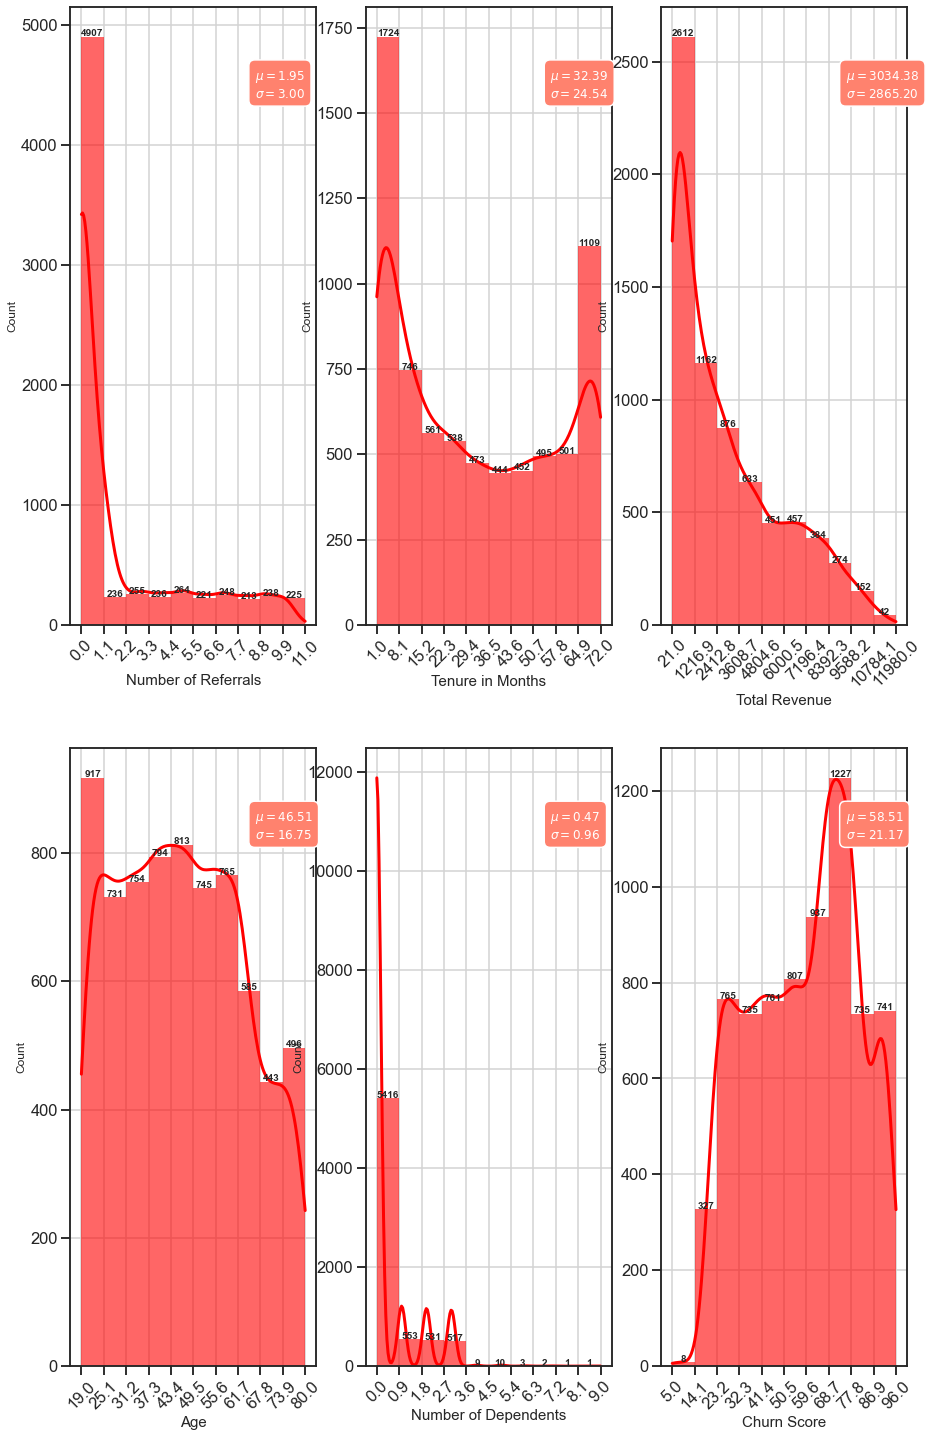

In [337]:
# Filter out continuous features for the univariate analysis
df_continuous=telecom_churn_df.select_dtypes(include=['float64', 'int64'])
df_continuous=df_continuous.drop(labels=["Latitude", 'Satisfaction Score',"Longitude",'Churn Value','Avg Monthly Long Distance Charges', 'Avg Monthly GB Download','Monthly Charge', 'Total Charges', 'Total Refunds','Total Extra Data Charges', 'Total Long Distance Charges',],axis=1)
import numpy as np
# Set up the subplot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 25))

# Loop to plot histograms for each continuous feature
for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3
    values, bin_edges = np.histogram(df_continuous[col], 
                                     range=(np.floor(df_continuous[col].min()), np.ceil(df_continuous[col].max())))
    
    graph = sns.histplot(data=df_continuous, x=col, bins=bin_edges, kde=True, ax=ax[x, y],
                         edgecolor='none', color='red', alpha=0.6, line_kws={'lw': 3})
    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')
    
    for j, p in enumerate(graph.patches):
        ax[x, y].annotate('{}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                          ha='center', fontsize=10, fontweight="bold")
    
    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))
    ax[x, y].text(0.75, 0.9, textstr, transform=ax[x, y].transAxes, fontsize=12, verticalalignment='top',
                  color='white', bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5))

ax[1,2].axis('off')
plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [338]:
cat_col=telecom_churn_df.select_dtypes(include=['object'])
df_copy=cat_col
len(df_copy.columns)

23

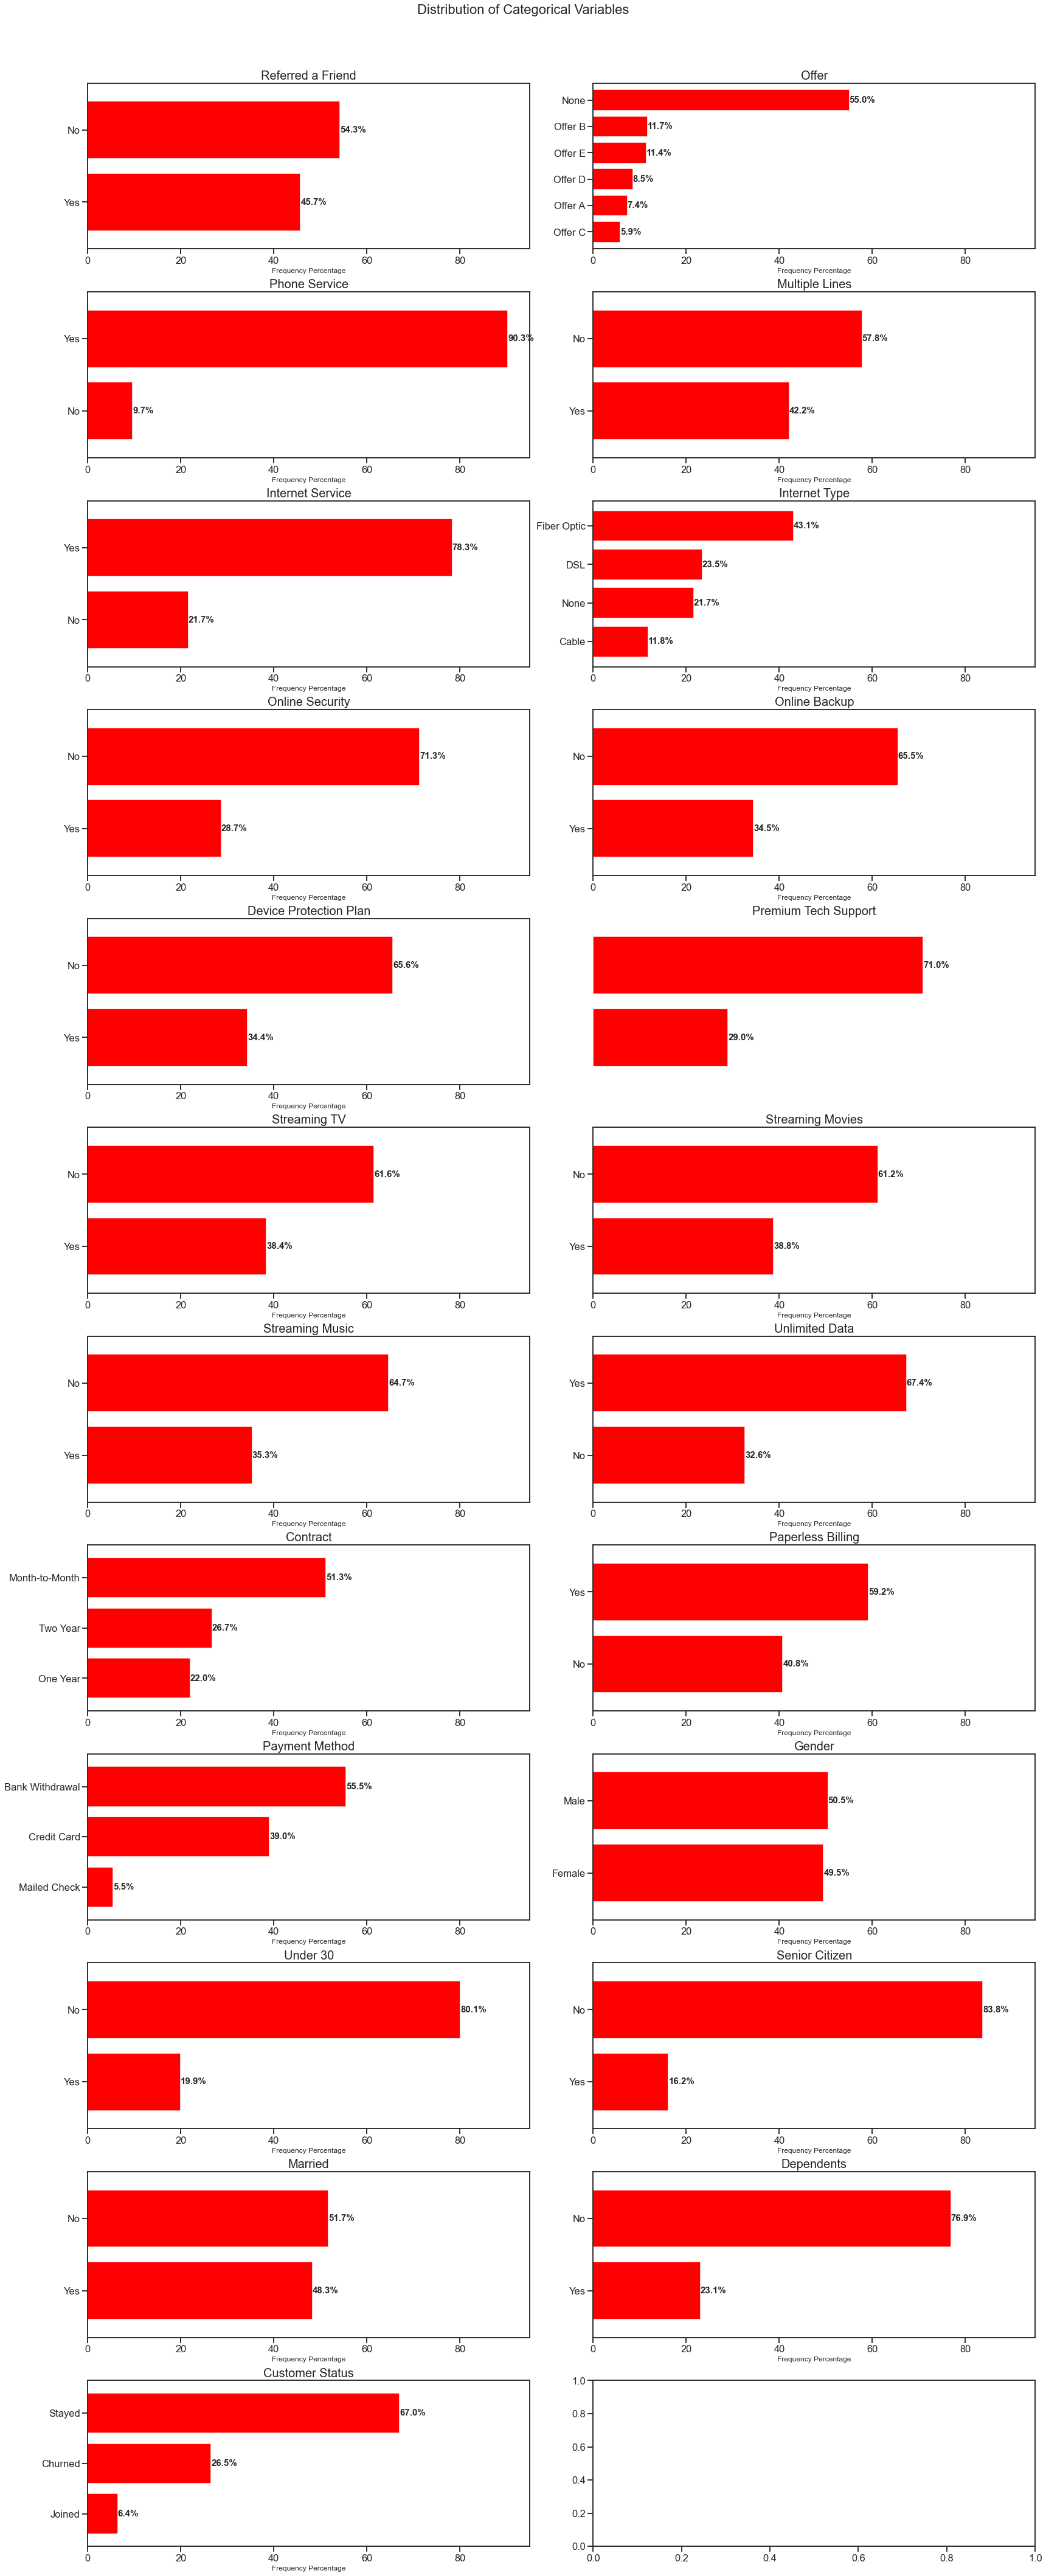

In [339]:
categorical_features = cat_col.columns
df_categorical = cat_col
# Set up the subplot for a 4x2 layout
fig, ax = plt.subplots(nrows=12, ncols=2, figsize=(24, 60))

# Loop to plot bar charts for each categorical feature in the 4x2 layout
for i, col in enumerate(categorical_features):
    row = i // 2
    col_idx = i % 2
    
    # Calculate frequency percentages
    value_counts = df_copy[col].value_counts(normalize=True).mul(100).sort_values()
    
    # Plot bar chart
    value_counts.plot(kind='barh', ax=ax[row, col_idx], width=0.8, color='red')
    
    # Add frequency percentages to the bars
    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(value, index, str(round(value, 1)) + '%', fontsize=15, weight='bold', va='center')
    
    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(f'{col}', fontsize=20)

ax[4,1].axis('off')
plt.suptitle('Distribution of Categorical Variables', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

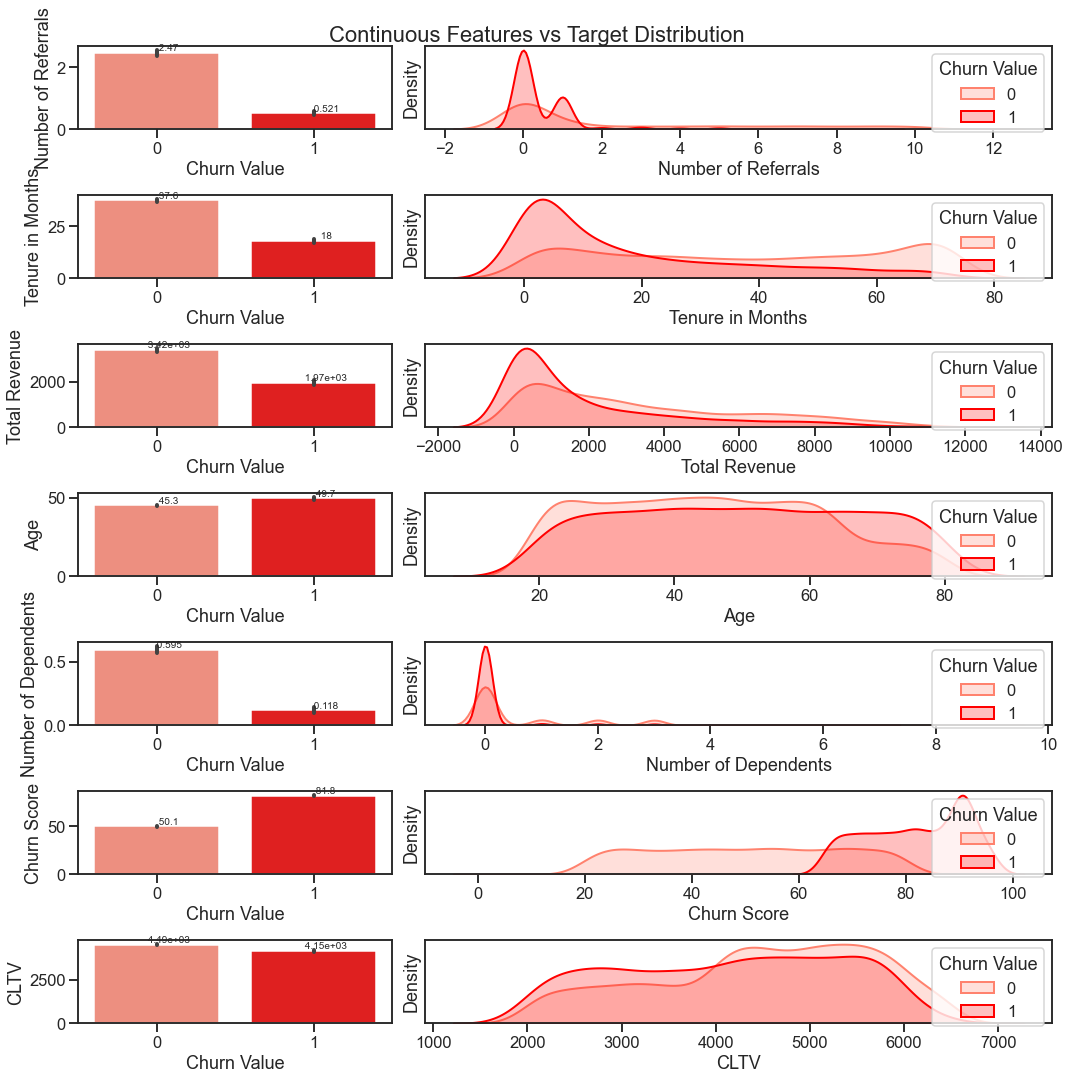

In [340]:
# Set color palette
sns.set_palette(['#ff826e', 'red'])
cont=df_continuous.columns
df_copy=telecom_churn_df

# Create the subplots
fig, ax = plt.subplots(len(cont), 2, figsize=(15,15), gridspec_kw={'width_ratios': [1, 2]})

# Loop through each continuous feature to create barplots and kde plots
for i, col in enumerate(cont):
    # Barplot showing the mean value of the feature for each target category
    graph = sns.barplot(data=telecom_churn_df, x="Churn Value", y=col, ax=ax[i,0])
    
    # KDE plot showing the distribution of the feature for each target category
    sns.kdeplot(data=df_copy[df_copy["Churn Value"]==0], x=col, fill=True, linewidth=2, ax=ax[i,1], label='0')
    sns.kdeplot(data=df_copy[df_copy["Churn Value"]==1], x=col, fill=True, linewidth=2, ax=ax[i,1], label='1')
    ax[i,1].set_yticks([])
    ax[i,1].legend(title='Churn Value', loc='upper right')
    
    # Add mean values to the barplot
    for cont in graph.containers:
        graph.bar_label(cont, fmt='         %.3g')
        
# Set the title for the entire figure
plt.suptitle('Continuous Features vs Target Distribution', fontsize=22)
plt.tight_layout()                     
plt.show()

In [341]:
telecom_churn_df["Payment Method"].value_counts()

Bank Withdrawal    3909
Credit Card        2749
Mailed Check        385
Name: Payment Method, dtype: int64

In [342]:
unique_payment_method_count = (telecom_churn_df['Payment Method'].value_counts() / len(telecom_churn_df)*100)#['payment_method'].value_counts().sum() * 100).tolist()

# unique payment method
unique_payment_method = telecom_churn_df['Payment Method'].value_counts().reset_index().rename(columns={'index': 'payment method', 'Payment Method': 'count'})
unique_payment_method['% payment split'] = ['{:.2f}'.format(x) for x in unique_payment_method_count]
unique_payment_method

,payment method,count,% payment split
0,Bank Withdrawal,3909,55.50
1,Credit Card,2749,39.03
2,Mailed Check,385,5.47


In [343]:
unique_payment_method_count

Bank Withdrawal    55.501917
Credit Card        39.031663
Mailed Check        5.466421
Name: Payment Method, dtype: float64

From the analysis above, we see that most Interconnect customers prefer month-to-month payment with 33% of payment done using this medium. Also, electronic check was frequently used to make payment amongst the payment method available.

### Can we deduce a relationship between payment method and total charges?

In [344]:
# total charges grouped by payment method
total_charges_grouped = telecom_churn_df.groupby('Payment Method', as_index=False).agg({'Total Charges': 'sum'}).sort_values(
    by='Total Charges', ascending=False, ignore_index=True)
total_charges_grouped

,Payment Method,Total Charges
0,Bank Withdrawal,9694327.65
1,Credit Card,5980741.34
2,Mailed Check,385656.25


We can agree that customers making payment with Bank withdrawal had the highest total charges. With this knowledge, marketing team can channel more marketing campaign to make these set of customers use more services. Customers who mail-in check on the other hand had the lowest total charges. Here, marketing team can device new marketing campaign to make the these sets of customers to embrace either the bank transfer method or the electronic check method. If we can get all the customers sending in mail-in checks to use the electronic check, then we would have more total customer charges which translate to more revenue for Interconnect telecom.

### Can we deduce a relationship between payment type and total monthly charges?

In [345]:
# total monthly charges grouped by payment type
(telecom_churn_df.groupby('Contract', as_index=False)
     .agg({'Monthly Charge': 'sum', 'Total Charges': 'sum'})
     .sort_values(by='Total Charges', ascending=False, ignore_index=True)
)

,Contract,Monthly Charge,Total Charges
0,Two Year,117580.15,6730701.55
1,Month-to-Month,236766.15,4698031.70
2,One Year,101770.30,4631991.99


We can see that customers on a two-year contract bring in more total revenue than customers on a one year contract. The marketing team at Interconnect can introduce more two year contract plan to entice more customers to sign up for a two year contract. 

### Services count by contract type

In [346]:
telecom_churn_df['service_count'] = [x.count('Yes') for x in zip(telecom_churn_df['Online Security'], telecom_churn_df['Online Backup'], telecom_churn_df['Device Protection Plan'], 
                                                           telecom_churn_df['Premium Tech Support'], telecom_churn_df['Streaming TV'], telecom_churn_df['Streaming Movies'], telecom_churn_df['Streaming Music'])]

In [347]:
# services count grouped by contract type
(telecom_churn_df.groupby('Contract', as_index=False)
     .agg({'service_count': 'sum'})
     .sort_values(by='service_count', ascending=False, ignore_index=True)
)

,Contract,service_count
0,Month-to-Month,6609
1,Two Year,5783
2,One Year,4449


We observe that customers on a month-to-month contract use more services than customers on a one year contract. This knowledge would inform advertisement campaigns and marketing efforts.

Text(0, 0.5, 'Number of Churned Customers')

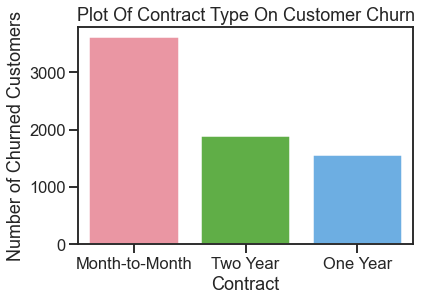

In [348]:
contract_churn = telecom_churn_df.groupby(['Contract'])['Churn Value'].count().sort_values(ascending=False).reset_index()
sns.barplot(x = 'Contract', y = 'Churn Value', data=contract_churn)
plt.title("Plot Of Contract Type On Customer Churn")
plt.ylabel("Number of Churned Customers")

     Offer  Churn Value % exit percent
0     None         1051          55.05
1  Offer E          426          11.70
2  Offer D          161          11.43
3  Offer B          101           8.55
4  Offer C           95           7.38
5  Offer A           35           5.89


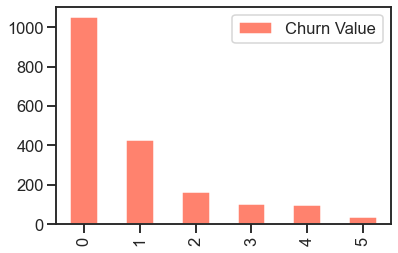

In [349]:
# effect of contract type on customer churn
contract_type_percent = telecom_churn_df.groupby(
    'Offer', as_index=False).agg(
    {'Churn Value': 'sum'}).sort_values(
    by='Churn Value', ascending=False, ignore_index=True)
contract_type_effect = (telecom_churn_df['Offer'].value_counts() / telecom_churn_df['Offer'].value_counts().sum() * 100).tolist()
contract_type_percent['% exit percent'] = ['{:.2f}'.format(x) for x in contract_type_effect]
contract_type_percent.plot(kind='bar')

print(contract_type_percent)

In [350]:
# function to plot seaborn barplot
def plot_snsbar(df, x, y, title):
    xlabel = str(x.replace('_', ' ').capitalize())
    ylabel = str(y.replace('_', ' ').capitalize())
    # create grouped data
    data = df.groupby([x])[y].count().sort_values(ascending=False).reset_index()
    fig, ax=plt.subplots(figsize=(10,6))
    ax = sns.barplot(x = x, y = y, data=data)
    ax.set_title(title, fontdict={'size':12})
    ax.set_ylabel(ylabel, fontsize = 10)
    ax.set_xlabel(xlabel, fontsize = 10)
    ax.set_xticklabels(data[x], rotation=90);

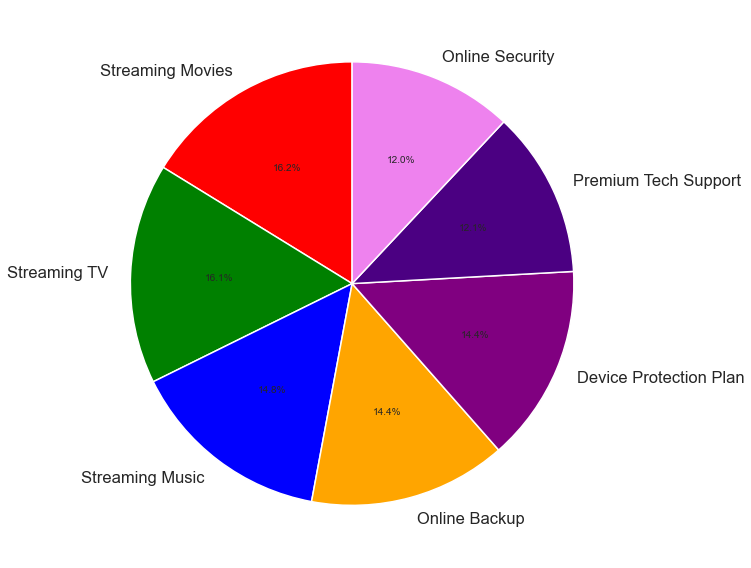

In [365]:
services=['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music']
services_count=telecom_churn_df[services].apply(lambda x: (x == "Yes").sum())

top_services=services_count.sort_values(ascending=False)
plt.figure(figsize=(12,8))
plt.pie(top_services, labels=top_services.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green','blue', 'orange', 'purple', 'indigo', 'violet'])
plt.tight_layout()
plt.show()

In [366]:
telecom_churn_df.groupby(['Satisfaction Score', 'Churn Value']).size().unstack(fill_value=0)

Churn Value,0,1
Satisfaction Score,,
1,0,922
2,0,518
3,2236,429
4,1789,0
5,1149,0


In [487]:
telecom_churn_dff=telecom_churn_df.drop(['Latitude', 'Longitude', 'Under 30', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', "Customer Status", 'Dependents', 'service_count', 'Churn Score', 'Total Revenue', 'CLTV', 'Unlimited Data','Device Protection Plan', 'Avg Monthly Long Distance Charges'], axis=1)

telecom_churn_dff.columns

Index(['Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type',
       'Avg Monthly GB Download', 'Online Security', 'Online Backup',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charge', 'Total Long Distance Charges', 'Gender', 'Age',
       'Senior Citizen', 'Married', 'Number of Dependents',
       'Satisfaction Score', 'Churn Value'],
      dtype='object')

In [488]:
### BEGIN SOLUTION
df_uniques = pd.DataFrame([[i, len(telecom_churn_dff[i].unique())] for i in telecom_churn_dff.columns], columns=['Variable', 'Unique Values']).set_index('Variable')
df_uniques

,Unique Values
Variable,
Referred a Friend,2
Number of Referrals,12
Tenure in Months,72
Offer,6
Phone Service,2
Multiple Lines,2
Internet Service,2
Internet Type,4
Avg Monthly GB Download,50


In [489]:
binary_variables = list(df_uniques[df_uniques['Unique Values'] == 2].index)
binary_variables.remove('Churn Value')

categorical_variables = list(df_uniques.select_dtypes(include=['object'])[(6 >= df_uniques['Unique Values']) & (df_uniques['Unique Values'] > 2)].index)
#categorical_variables.remove("Satisfaction Score")

[[i, list(telecom_churn_dff[i].unique())] for i in categorical_variables]

#ordinal_variables = ['Satisfaction Score']

[['Offer', ['None', 'Offer E', 'Offer D', 'Offer C', 'Offer B', 'Offer A']],
 ['Internet Type', ['DSL', 'Fiber Optic', 'Cable', 'None']],
 ['Contract', ['Month-to-Month', 'One Year', 'Two Year']],
 ['Payment Method', ['Bank Withdrawal', 'Credit Card', 'Mailed Check']],
 ['Satisfaction Score', [3, 2, 1, 4, 5]]]

In [490]:
numeric_variables = list(set(telecom_churn_dff.columns) - set(ordinal_variables) - set(categorical_variables) - set(binary_variables))
numeric_variables

['Monthly Charge',
 'Number of Referrals',
 'Avg Monthly GB Download',
 'Tenure in Months',
 'Total Long Distance Charges',
 'Number of Dependents',
 'Churn Value',
 'Age']

In [491]:
binary_variables

['Referred a Friend',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Paperless Billing',
 'Gender',
 'Senior Citizen',
 'Married']

In [492]:
categorical_variables

['Offer', 'Internet Type', 'Contract', 'Payment Method', 'Satisfaction Score']

In [493]:
telecom_churn_df[categorical_variables]

,Offer,Internet Type,Contract,Payment Method,Satisfaction Score
0,None,DSL,Month-to-Month,Bank Withdrawal,3
1,Offer E,Fiber Optic,Month-to-Month,Credit Card,3
2,Offer D,Fiber Optic,Month-to-Month,Bank Withdrawal,2
3,Offer C,Fiber Optic,Month-to-Month,Bank Withdrawal,2
4,Offer C,Fiber Optic,Month-to-Month,Bank Withdrawal,2
...,...,...,...,...,...
7038,None,None,Two Year,Bank Withdrawal,5
7039,Offer C,Cable,One Year,Mailed Check,3
7040,None,Fiber Optic,One Year,Credit Card,4
7041,None,DSL,Month-to-Month,Bank Withdrawal,4


In [494]:
list[(numeric_variables)]

list[['Monthly Charge', 'Number of Referrals', 'Avg Monthly GB Download', 'Tenure in Months', 'Total Long Distance Charges', 'Number of Dependents', 'Churn Value', 'Age']]

In [495]:
ohe=OneHotEncoder(handle_unknown='ignore', sparse_output=False)      
encoded=ohe.fit_transform(telecom_churn_dff[binary_variables])
encoded_df=pd.DataFrame(encoded, columns=ohe.get_feature_names_out(binary_variables))
telecom_churn_dff=telecom_churn_dff.drop(columns=binary_variables).reset_index(drop=True)
telecom_churn_dff=pd.concat([telecom_churn_dff, encoded_df], axis=1)

In [496]:
label_encoders = {}

for cols in categorical_variables:
    le = LabelEncoder()
    telecom_churn_dff[cols] = le.fit_transform(telecom_churn_dff[cols].astype(str).str.lower().str.strip())
    label_encoders[cols] = le

In [512]:
joblib.dump(ohe, "onehot_encoders.pkl")

['onehot_encoders.pkl']

In [497]:

joblib.dump(telecom_churn_dff.columns, "columns.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [498]:
telecom_churn_dff.to_csv("telecom_churn_df")

In [499]:
df=telecom_churn_dff
y = df['Churn Value']
X = df.drop(['Churn Value'], axis=1)

# split data into 75% training and 25% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)

In [500]:
X_train.columns

Index(['Number of Referrals', 'Tenure in Months', 'Offer', 'Internet Type',
       'Avg Monthly GB Download', 'Contract', 'Payment Method',
       'Monthly Charge', 'Total Long Distance Charges', 'Age',
       'Number of Dependents', 'Satisfaction Score', 'Referred a Friend_No',
       'Referred a Friend_Yes', 'Phone Service_No', 'Phone Service_Yes',
       'Multiple Lines_No', 'Multiple Lines_Yes', 'Internet Service_No',
       'Internet Service_Yes', 'Online Security_No', 'Online Security_Yes',
       'Online Backup_No', 'Online Backup_Yes', 'Premium Tech Support_No',
       'Premium Tech Support_Yes', 'Streaming TV_No', 'Streaming TV_Yes',
       'Streaming Movies_No', 'Streaming Movies_Yes', 'Streaming Music_No',
       'Streaming Music_Yes', 'Paperless Billing_No', 'Paperless Billing_Yes',
       'Gender_Female', 'Gender_Male', 'Senior Citizen_No',
       'Senior Citizen_Yes', 'Married_No', 'Married_Yes'],
      dtype='object')

In [501]:
ss=StandardScaler()
X_train_scaled=ss.fit_transform(X_train)
X_test_scaled=ss.transform(X_test)

In [502]:
X_train_scaled_df=pd.DataFrame(X_train_scaled, columns=X_train.columns)

## MODEL BUILDING AND EVALUATION

In [503]:
# function to calculate model evaluation metrics
def print_model_evaluation(y_test, test_predictions):
    print("\033[1m" + 'F1 score: ' + "\033[0m", '{:.3f}'.format(f1_score(y_test, test_predictions)))
    print("\033[1m" + 'Accuracy Score: ' + "\033[0m", '{:.2%}'.format(accuracy_score(y_test, test_predictions)))
    print("\033[1m" + 'Precision: ' + "\033[0m", '{:.3f}'.format(precision_score(y_test, test_predictions)))
    print("\033[1m" + 'Recall: ' + "\033[0m", '{:.3f}'.format(recall_score(y_test, test_predictions)))
    print("\033[1m" + 'Balanced Accuracy Score: ' + "\033[0m", '{:.2%}'.format(balanced_accuracy_score(y_test, test_predictions)))
    print("\033[1m" + 'AUC-ROC Score: ' + "\033[0m", '{:.2%}'.format(roc_auc_score(y_test, test_predictions)))
    print()
    print("\033[1m" + 'Confusion Matrix' + "\033[0m")
    print('-'*50)
    print(confusion_matrix(y_test, test_predictions))
    print()
    print("\033[1m" + 'Classification report' + "\033[0m")
    print('-'*50)
    print(classification_report(y_test, test_predictions))
    print()

In [504]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_scaled, y_train)
dummy_clf_test_predictions = dummy_clf.predict(X_test_scaled)

In [505]:
# evaluate baseline model
print_model_evaluation(y_test, dummy_clf_test_predictions)

F1 score:  0.000
Accuracy Score:  72.86%
Precision:  0.000
Recall:  0.000
Balanced Accuracy Score:  50.00%
AUC-ROC Score:  50.00%

Confusion Matrix
--------------------------------------------------
[[1283    0]
 [ 478    0]]

Classification report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1283
           1       0.00      0.00      0.00       478

    accuracy                           0.73      1761
   macro avg       0.36      0.50      0.42      1761
weighted avg       0.53      0.73      0.61      1761




In [506]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, classification_report
def model_eval(y_true, y_pred, y_prob=None):
    metrics={
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_pred)
    }
    print("Model Evaluation Metrics: ")
    print("-"*40)
    for k,v in metrics.items():
        print(f"{k: 10}: {v:.4f}" if isinstance(v,float) else f"{k:10}: {v}")
    print("-" * 40)
    
    return metrics

In [507]:
def plot_confusion_matrix(y, y_predict):
    "this function plots the confusion matrix"
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not churn', 'churn']); ax.yaxis.set_ticklabels(['did not churn', 'churn'])

# Logistic Regression

In [508]:
from sklearn.linear_model import LogisticRegressionCV
# L1 regularized logistic regression
#lr_l1 = LogisticRegression()

In [509]:
# Grid search hyperparameters for a logistic regression model
rs=123

def grid_search_lr(X_train, y_train):
    params_grid = {
    'class_weight': [{0:0.05, 1:0.95}, {0:0.1, 1:0.9}, {0:0.2, 1:0.8}, {0:0.3, 1:0.7}, {0:0.4, 1:0.6}],
    'penalty':['l1', 'l2', 'elasticnet'],
    'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
    }
    lr_model = LogisticRegression(random_state=rs, max_iter=1000)
    grid_search = GridSearchCV(estimator = lr_model, 
                           param_grid = params_grid, 
                           scoring='f1',
                           cv = 5, verbose = 1)
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    return best_params

In [118]:
user_input = pd.DataFrame([colss], columns=columns)
pred_encoded = lr_model.predict(user_input)#[0]

pred_encoded

array([1], dtype=int64)

In [56]:
start_time = time.perf_counter()
grid_search_lr(X_train_scaled, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


{'class_weight': {0: 0.4, 1: 0.6}, 'penalty': 'l2', 'solver': 'newton-cg'}

In [116]:
lr_model = LogisticRegression(penalty = 'l2',random_state=rs, max_iter = 1000,solver='newton-cg')
    # Train the model
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=123, solver='newton-cg')

In [428]:
%%time

UsageError: %%time is a cell magic, but the cell body is empty. Did you mean the line magic %time (single %)?


F1 score:  0.930
Accuracy Score:  96.31%
Precision:  0.952
Recall:  0.910
Balanced Accuracy Score:  94.64%
AUC-ROC Score:  94.64%

Confusion Matrix
--------------------------------------------------
[[1261   22]
 [  43  435]]

Classification report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1283
           1       0.95      0.91      0.93       478

    accuracy                           0.96      1761
   macro avg       0.96      0.95      0.95      1761
weighted avg       0.96      0.96      0.96      1761


CPU times: total: 1.05 s
Wall time: 1.06 s


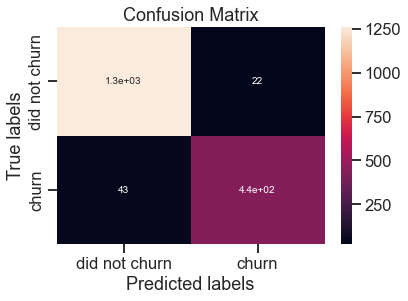

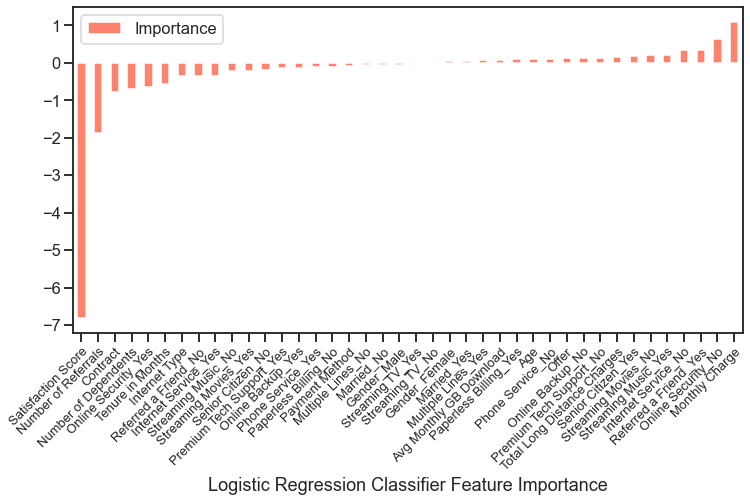

In [510]:
%%time

def build_lr(X_train, y_train, X_test, threshold=0.5, best_params=None):
    
    model = LogisticRegression(random_state=rs, 
                              max_iter = 1000)
    # If best parameters are provided
    if best_params:
        model = LogisticRegression(penalty = 'l2',
                              random_state=rs, 
                              max_iter = 1000,
                              solver='newton-cg',
                              class_weight=best_params['class_weight'])
    # Train the model
    model.fit(X_train, y_train)
    # If predicted probability is largr than threshold (default value is 0.5), generate a positive label
    predicted_proba = model.predict_proba(X_test)
    yp = (predicted_proba [:,1] >= threshold).astype('int')
    model_eval=print_model_evaluation(y_test, yp)
    cm=plot_confusion_matrix(y_test, yp)
    log_model_importance = pd.DataFrame(
    model.coef_[0], index=X.columns, columns=["Importance"]
    )
    # plot the chart
    log_model_importance.sort_values(by="Importance").plot(kind="bar", figsize=(12, 6))
    plt.xticks(rotation=45, ha="right", rotation_mode="anchor", fontsize=13)
    plt.xlabel("Logistic Regression Classifier Feature Importance")
    return yp, model, model_eval, cm
    
    

model_lr=build_lr(X_train_scaled, y_train, X_test_scaled, threshold=0.5)

In [511]:
import joblib
joblib.dump(model_lr,'Logistic_Regression.pkl')

['Logistic_Regression.pkl']

# Random Forest Classifier

In [513]:
# Grid search hyperparameters for a random forest model
start_time = time.perf_counter()
def grid_search_rf(X_train, y_train):
    params_grid = {
    'max_depth': [5, 10, 15, 20],
    'n_estimators': [25, 50, 100],
    'min_samples_split': [2, 5],
    'class_weight': [{0:0.1, 1:0.9}, {0:0.2, 1:0.8}, {0:0.3, 1:0.7}]
    }
    rf_model = RandomForestClassifier(random_state=rs)
    grid_search = GridSearchCV(estimator = rf_model, 
                           param_grid = params_grid, 
                           scoring='f1',
                           cv = 5, verbose = 1)
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    return best_params


In [147]:
time.time()
grid_search_rf(X_train_scaled, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


{'class_weight': {0: 0.3, 1: 0.7},
 'max_depth': 20,
 'min_samples_split': 5,
 'n_estimators': 25}

F1 score:  0.936
Accuracy Score:  96.65%
Precision:  0.973
Recall:  0.902
Balanced Accuracy Score:  94.62%
AUC-ROC Score:  94.62%

Confusion Matrix
--------------------------------------------------
[[1271   12]
 [  47  431]]

Classification report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1283
           1       0.97      0.90      0.94       478

    accuracy                           0.97      1761
   macro avg       0.97      0.95      0.96      1761
weighted avg       0.97      0.97      0.97      1761


CPU times: total: 2.31 s
Wall time: 2.82 s


(array([0, 0, 1, ..., 0, 0, 1]),
 RandomForestClassifier(random_state=123),
 None,
 None)

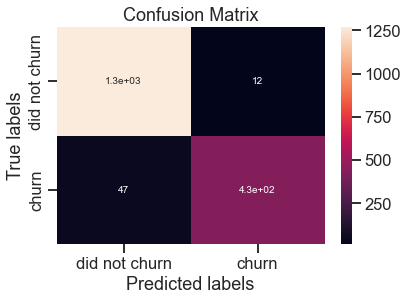

In [515]:
%%time
def build_rf(X_train, y_train, X_test, threshold=0.5, best_params=None):
    
    model = RandomForestClassifier(random_state = rs)
    # If best parameters are provided
    if best_params:
        model = RandomForestClassifier(random_state = rs,
                                   # If bootstrap sampling is used
                                   bootstrap = best_params['bootstrap'],
                                   # Max depth of each tree
                                   max_depth = best_params['max_depth'],
                                   # Class weight parameters
                                   class_weight=best_params['class_weight'],
                                   # Number of trees
                                   n_estimators=best_params['n_estimators'],
                                   # Minimal samples to split
                                   min_samples_split=best_params['min_samples_split'])
    # Train the model   
    model.fit(X_train, y_train)
    # If predicted probability is largr than threshold (default value is 0.5), generate a positive label
    predicted_proba = model.predict_proba(X_test)
    yp = (predicted_proba [:,1] >= threshold).astype('int')
    model_eval=print_model_evaluation(y_test, yp)
    cm=plot_confusion_matrix(y_test, yp)
    return yp, model, model_eval, cm

build_rf(X_train_scaled, y_train, X_test_scaled, threshold=0.5)

# Decision Tree Classifier

In [517]:
# Grid search hyperparameters for a random forest model
def grid_search_dt(X_train, y_train):
    params_grid = {
    "criterion" : ["gini", "entropy", "logloss"],
    "max_depth" : [None, 2, 4, 8, 10, 12],
    "min_samples_split" : [2, 4, 8, 16],
    "min_samples_leaf" : [2, 4, 6]
}
    dt_model = DecisionTreeClassifier(random_state=rs)
    grid_search = GridSearchCV(estimator = dt_model, 
                           param_grid = params_grid, 
                           scoring='f1',
                           cv = 5, verbose = 1)
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    return best_params


In [153]:
%time
grid_search_dt(X_train_scaled, y_train)

CPU times: total: 0 ns
Wall time: 0 ns
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


{'criterion': 'entropy',
 'max_depth': 8,
 'min_samples_leaf': 6,
 'min_samples_split': 16}

F1 score:  0.936
Accuracy Score:  96.65%
Precision:  0.973
Recall:  0.902
Balanced Accuracy Score:  94.62%
AUC-ROC Score:  94.62%

Confusion Matrix
--------------------------------------------------
[[1271   12]
 [  47  431]]

Classification report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1283
           1       0.97      0.90      0.94       478

    accuracy                           0.97      1761
   macro avg       0.97      0.95      0.96      1761
weighted avg       0.97      0.97      0.97      1761


CPU times: total: 2.95 s
Wall time: 3.2 s


(array([0, 0, 1, ..., 0, 0, 1]),
 RandomForestClassifier(random_state=123),
 None,
 None)

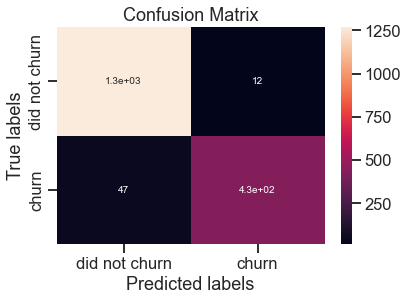

In [518]:
%%time
def build_dt(X_train, y_train, X_test, threshold=0.5, best_params=None):
    
    model = RandomForestClassifier(random_state = rs)
    # If best parameters are provided
    if best_params:
        model = DecisionTreeClassifier(random_state = rs,
                                   # If bootstrap sampling is used
                                   criterion = best_params['criterion'],
                                   # Max depth of each tree
                                   max_depth = best_params['max_depth'],
                                   # Class weight parameters
                                   #class_weight=best_params['class_weight'],
                                   # Number of trees
                                   min_samples_leaf=best_params['min_samples_leaf'],
                                   # Minimal samples to split
                                   min_samples_split=best_params['min_samples_split'])
    # Train the model   
    model.fit(X_train, y_train)
    # If predicted probability is largr than threshold (default value is 0.5), generate a positive label
    predicted_proba = model.predict_proba(X_test)
    yp = (predicted_proba [:,1] >= threshold).astype('int')
    model_eval=print_model_evaluation(y_test, yp)
    cm=plot_confusion_matrix(y_test, yp)
    rf_model_importance = pd.DataFrame(
    model.coef_[0], index=X.columns, columns=["Importance"]
    )
    # plot the chart
    rf_model_importance.sort_values(by="Importance").plot(kind="bar", figsize=(12, 6))
    plt.xticks(rotation=45, ha="right", rotation_mode="anchor", fontsize=13)
    plt.xlabel("Random Forest Classifier Feature Importance")
    return yp, model, model_eval, cm

build_rf(X_train_scaled, y_train, X_test_scaled, threshold=0.5)

# KNN Classifier

In [519]:
from sklearn.neighbors import KNeighborsClassifier
max_k = 50
f1_scores = list()
error_rates = list() # 1-accuracy

for k in range(1, max_k):
    
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn = knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    f1 = f1_score(y_pred, y_test)
    f1_scores.append((k, round(f1_score(y_test, y_pred), 4)))
    error = 1-round(accuracy_score(y_test, y_pred), 4)
    error_rates.append((k, error))
f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])
f1_results

,K,F1 Score
0,1,0.7233
1,2,0.7233
2,3,0.7325
3,4,0.7445
4,5,0.7604
5,6,0.7618
6,7,0.7772
7,8,0.7715
8,9,0.7812
9,10,0.7827


<Figure size 1800x1200 with 0 Axes>

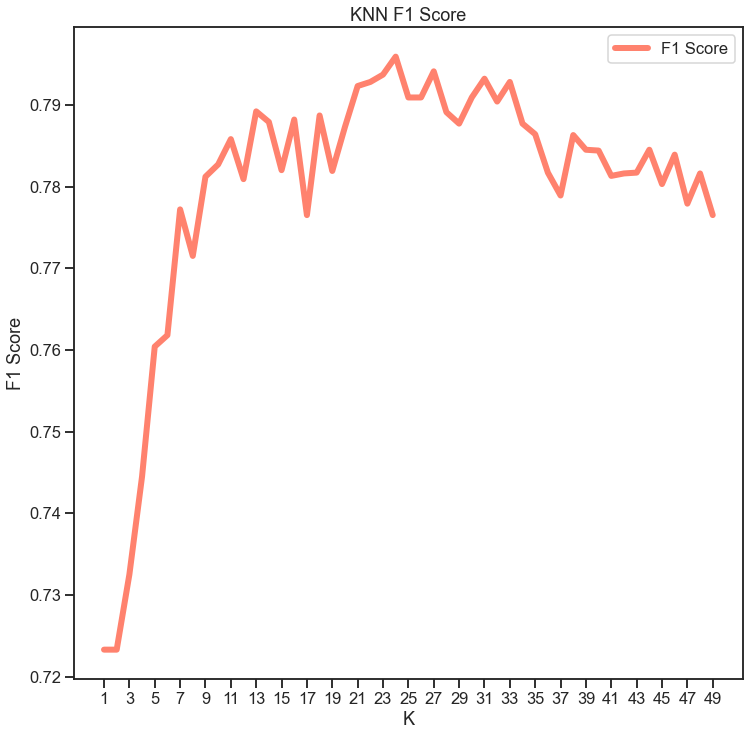

In [520]:
# Plot F1 results
sns.set_context('talk')
sns.set_style('ticks')

plt.figure(dpi=300)
ax = f1_results.set_index('K').plot(figsize=(12, 12), linewidth=6)
ax.set(xlabel='K', ylabel='F1 Score')
ax.set_xticks(range(1, max_k, 2));
plt.title('KNN F1 Score')
plt.savefig('knn_f1.png')

F1 score:  0.787
Accuracy Score:  88.81%
Precision:  0.816
Recall:  0.759
Balanced Accuracy Score:  84.78%
AUC-ROC Score:  84.78%

Confusion Matrix
--------------------------------------------------
[[1201   82]
 [ 115  363]]

Classification report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1283
           1       0.82      0.76      0.79       478

    accuracy                           0.89      1761
   macro avg       0.86      0.85      0.86      1761
weighted avg       0.89      0.89      0.89      1761


CPU times: total: 1.3 s
Wall time: 1.11 s


(array([0, 0, 1, ..., 0, 0, 1]),
 KNeighborsClassifier(n_neighbors=16),
 None,
 None)

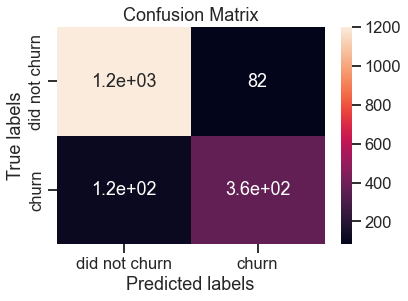

In [521]:
%%time
def build_knn(X_train, y_train, X_test, threshold=0.5, best_params=None):
    
    model = KNeighborsClassifier(n_neighbors=16)
    # Train the model   
    model.fit(X_train, y_train)
    # If predicted probability is largr than threshold (default value is 0.5), generate a positive label
    predicted_proba = model.predict_proba(X_test)
    yp = (predicted_proba [:,1] >= threshold).astype('int')
    model_eval=print_model_evaluation(y_test, yp)
    cm=plot_confusion_matrix(y_test, yp)
    
    return yp, model, model_eval, cm

build_knn(X_train_scaled, y_train, X_test_scaled, threshold=0.5)

# CONCLUSION

Among all the models evaluated, Logistic Regression proved to be the best performer, achieving an accuracy of 96.31%, f1 score of 0.930, recall of 0.910 and an AUC-ROC of 94.64%. The confusion matrix also shows minimal misclassification with only 22 false positives and 43 false negatives out of 1761 samples.

In churn prediction, recall is critical. it is more costly to miss a customer who is about to churn than to flag one who isn't. With a recall of 0.910, the model correctly identifies 91% of actual people that churned, allowing the businesss to intervene early. The high precision of 0.952 also ensures thatretention efforts are not wasted pn customers who were never at risk. 
Beyond these metrics, Logistic Regression completed training inn just over 1 second, making it highly efficient for retraining on fresh customer data as business conditions change.

Overall, Logistic Regression shows the ideal balance of accuracy, recall, precision, f1 score, speed, and interpretability, making it the optimal model for this telecom churn prediction.